# AgentClinic: three-seed baseline vs PNLC analysis

This notebook analyzes the 107 AgentClinic MedQA scenarios for matched seeds 11, 22, and 33. It uses the **first completed seed-22 PNLC run** in the primary analysis so that the run is not selected because it obtained the higher score; the later complete seed-22 run is retained as a sensitivity check.

> **Status: preliminary / pre-fix evidence.** The saved runs predate the current candidate-diversity and symmetric final-diagnosis fixes. The notebook therefore reports the outcome estimates and the protocol/data-integrity failures together. These artifacts should not be treated as the final paper results.


In [1]:
from pathlib import Path
from collections import Counter
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.stats import binomtest
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 140)
plt.style.use('seaborn-v0_8-whitegrid')

def find_repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'logs').is_dir() and (candidate / 'external/AgentClinic/agentclinic_medqa.jsonl').is_file():
            return candidate.resolve()
    raise FileNotFoundError('Run this notebook from inside the pnlc-agentclinic repository.')

ROOT = find_repo_root()
LOGS = ROOT / 'logs'
ANALYSIS_DIR = ROOT / 'docs' / 'analysis'
FIGURE_DIR = ROOT / 'docs' / 'figures'
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATASET_PATH = ROOT / 'external' / 'AgentClinic' / 'agentclinic_medqa.jsonl'

PRIMARY_RUNS = [
    {'condition': 'Baseline', 'seed': 11, 'results_file': 'stage1_baseline_1785436682.json', 'trajectory_file': 'stage1_trajectories_1785436682.json'},
    {'condition': 'PNLC',     'seed': 11, 'results_file': 'stage1_pnlc_results_1785674416.json', 'trajectory_file': 'stage1_pnlc_trajectories_1785674416.json'},
    {'condition': 'Baseline', 'seed': 22, 'results_file': 'stage1_baseline_1785496588.json', 'trajectory_file': 'stage1_trajectories_1785496588.json'},
    {'condition': 'PNLC',     'seed': 22, 'results_file': 'stage1_pnlc_results_1785776758.json', 'trajectory_file': 'stage1_pnlc_trajectories_1785776758.json'},
    {'condition': 'Baseline', 'seed': 33, 'results_file': 'stage1_baseline_1785537280.json', 'trajectory_file': 'stage1_trajectories_1785537280.json'},
    {'condition': 'PNLC',     'seed': 33, 'results_file': 'stage1_pnlc_results_1786101626.json', 'trajectory_file': 'stage1_pnlc_trajectories_1786101626.json'},
]
AUXILIARY_RUNS = [
    {'condition': 'PNLC', 'seed': 22, 'results_file': 'stage1_pnlc_results_1785946363.json', 'trajectory_file': 'stage1_pnlc_trajectories_1785946363.json', 'role': 'later duplicate seed-22 sensitivity'},
]
manifest = pd.DataFrame(PRIMARY_RUNS)
manifest['analysis_role'] = 'primary'
aux_manifest = pd.DataFrame(AUXILIARY_RUNS)
aux_manifest['analysis_role'] = 'sensitivity only'
display(pd.concat([manifest, aux_manifest], ignore_index=True))


,condition,seed,results_file,trajectory_file,analysis_role,role
0,Baseline,11,stage1_baseline_1785436682.json,stage1_trajectories_1785436682.json,primary,NaN
1,PNLC,11,stage1_pnlc_results_1785674416.json,stage1_pnlc_trajectories_1785674416.json,primary,NaN
2,Baseline,22,stage1_baseline_1785496588.json,stage1_trajectories_1785496588.json,primary,NaN
3,PNLC,22,stage1_pnlc_results_1785776758.json,stage1_pnlc_trajectories_1785776758.json,primary,NaN
4,Baseline,33,stage1_baseline_1785537280.json,stage1_trajectories_1785537280.json,primary,NaN
5,PNLC,33,stage1_pnlc_results_1786101626.json,stage1_pnlc_trajectories_1786101626.json,primary,NaN
6,PNLC,22,stage1_pnlc_results_1785946363.json,stage1_pnlc_trajectories_1785946363.json,sensitivity only,later duplicate seed-22 sensitivity


## 1. Load and validate the run artifacts

The result files already contain explicit scenario IDs. In particular, baseline seed 11 includes an explicit no-diagnosis result for scenario 10; it must remain in the denominator. No trajectory-order realignment is performed.


In [2]:
def read_json(path):
    with path.open() as handle:
        return json.load(handle)

def norm_text(value):
    return re.sub(r'\s+', ' ', str(value or '')).strip().casefold()

with DATASET_PATH.open() as handle:
    cases = [json.loads(line) for line in handle if line.strip()]
assert len(cases) == 107
references = {i: case['OSCE_Examination']['Correct_Diagnosis'] for i, case in enumerate(cases)}
questions = {i: case['OSCE_Examination']['Objective_for_Doctor'] for i, case in enumerate(cases)}

def load_and_validate(row, role):
    results_path = LOGS / row.results_file
    trajectory_path = LOGS / row.trajectory_file
    if not results_path.is_file() or not trajectory_path.is_file():
        raise FileNotFoundError(f'Missing artifact for {row.condition} seed {row.seed}')
    results = pd.DataFrame(read_json(results_path))
    trajectories = pd.DataFrame(read_json(trajectory_path))
    expected_ids = set(range(107))
    assert len(results) == 107 and set(results['scenario_index']) == expected_ids
    assert not results['scenario_index'].duplicated().any()
    assert set(results['run_seed'].astype(int)) == {int(row.seed)}
    assert set(trajectories['run_seed'].astype(int)) == {int(row.seed)}
    assert set(trajectories['scenario_index'].astype(int)) == expected_ids
    assert not trajectories.duplicated(['scenario_index', 'turn_index']).any()
    for scenario_index, group in trajectories.groupby('scenario_index'):
        turns = sorted(group['turn_index'].astype(int).tolist())
        assert turns == list(range(1, max(turns) + 1))
    assert all(norm_text(item.correct_diagnosis) == norm_text(references[int(item.scenario_index)]) for item in results.itertuples())
    terminal = trajectories.sort_values('turn_index').groupby('scenario_index').tail(1)
    terminal_marker = set(terminal.loc[terminal['doctor_action'].fillna('').str.upper().str.contains('DIAGNOSIS READY:', regex=False), 'scenario_index'].astype(int))
    reached_ids = set(results.loc[results['reached_diagnosis'].astype(bool), 'scenario_index'].astype(int))
    assert reached_ids == terminal_marker
    results = results.assign(condition=row.condition, seed=int(row.seed), analysis_role=role, results_file=row.results_file)
    trajectories = trajectories.assign(condition=row.condition, seed=int(row.seed), analysis_role=role, trajectory_file=row.trajectory_file)
    validation = {
        'condition': row.condition, 'seed': int(row.seed), 'analysis_role': role,
        'results_file': row.results_file, 'trajectory_file': row.trajectory_file,
        'result_rows': len(results), 'trajectory_rows': len(trajectories),
        'result_scenario_coverage': len(set(results.scenario_index)), 'trajectory_scenario_coverage': len(set(trajectories.scenario_index)),
        'diagnoses_reached': int(results.reached_diagnosis.astype(bool).sum()),
        'correct': int(results.correct.astype(bool).sum()), 'validation': 'PASS',
    }
    return results, trajectories, validation

result_frames, trajectory_frames, validation_rows = [], [], []
for row in manifest.itertuples(index=False):
    result, trajectory, validation = load_and_validate(row, 'primary')
    result_frames.append(result); trajectory_frames.append(trajectory); validation_rows.append(validation)
results = pd.concat(result_frames, ignore_index=True)
trajectories = pd.concat(trajectory_frames, ignore_index=True)

aux_result_frames, aux_trajectory_frames = [], []
for row in aux_manifest.itertuples(index=False):
    result, trajectory, validation = load_and_validate(row, 'sensitivity only')
    aux_result_frames.append(result); aux_trajectory_frames.append(trajectory); validation_rows.append(validation)
aux_results = pd.concat(aux_result_frames, ignore_index=True)
aux_trajectories = pd.concat(aux_trajectory_frames, ignore_index=True)
validation_table = pd.DataFrame(validation_rows)
validation_table.to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_run_validation.csv', index=False)
display(validation_table)


,condition,seed,analysis_role,results_file,trajectory_file,result_rows,trajectory_rows,result_scenario_coverage,trajectory_scenario_coverage,diagnoses_reached,correct,validation
0,Baseline,11,primary,stage1_baseline_1785436682.json,stage1_trajectories_1785436682.json,107,1655,107,107,106,58,PASS
1,PNLC,11,primary,stage1_pnlc_results_1785674416.json,stage1_pnlc_trajectories_1785674416.json,107,2095,107,107,107,57,PASS
2,Baseline,22,primary,stage1_baseline_1785496588.json,stage1_trajectories_1785496588.json,107,1606,107,107,107,56,PASS
3,PNLC,22,primary,stage1_pnlc_results_1785776758.json,stage1_pnlc_trajectories_1785776758.json,107,2027,107,107,107,61,PASS
4,Baseline,33,primary,stage1_baseline_1785537280.json,stage1_trajectories_1785537280.json,107,1614,107,107,107,55,PASS
5,PNLC,33,primary,stage1_pnlc_results_1786101626.json,stage1_pnlc_trajectories_1786101626.json,107,2044,107,107,107,58,PASS
6,PNLC,22,sensitivity only,stage1_pnlc_results_1785946363.json,stage1_pnlc_trajectories_1785946363.json,107,1997,107,107,107,64,PASS


## 2. Matched outcome analysis

Every comparison is paired by `(seed, scenario_index)`. The primary uncertainty interval resamples the 107 scenario clusters while retaining all three seeds for each sampled scenario. A scenario-cluster sign-flip test is also reported. This interval is conditional on the three seeds that were run; it quantifies scenario uncertainty, not generalization to arbitrary random seeds.


In [3]:
def make_pairs(result_frame):
    keep = ['seed', 'scenario_index', 'correct', 'reached_diagnosis', 'doctor_diagnosis_text', 'correct_diagnosis']
    baseline = result_frame[result_frame.condition == 'Baseline'][keep].copy()
    pnlc = result_frame[result_frame.condition == 'PNLC'][keep].copy()
    paired = baseline.merge(pnlc, on=['seed', 'scenario_index'], suffixes=('_baseline', '_pnlc'), validate='one_to_one')
    paired['correct_baseline'] = paired['correct_baseline'].astype(bool)
    paired['correct_pnlc'] = paired['correct_pnlc'].astype(bool)
    paired['delta'] = paired['correct_pnlc'].astype(int) - paired['correct_baseline'].astype(int)
    paired['outcome'] = np.select(
        [paired.correct_baseline & paired.correct_pnlc, ~paired.correct_baseline & paired.correct_pnlc, paired.correct_baseline & ~paired.correct_pnlc],
        ['Both correct', 'PNLC rescue', 'PNLC harm'], default='Both wrong')
    return paired

pairs = make_pairs(results)
assert len(pairs) == 321 and pairs.groupby('seed').size().eq(107).all()
OUTCOME_ORDER = ['Both correct', 'PNLC rescue', 'PNLC harm', 'Both wrong']

seed_rows = []
for seed, group in pairs.groupby('seed'):
    counts = group.outcome.value_counts()
    rescue, harm = int(counts.get('PNLC rescue', 0)), int(counts.get('PNLC harm', 0))
    seed_rows.append({
        'seed': int(seed), 'n': len(group),
        'baseline_correct': int(group.correct_baseline.sum()), 'baseline_accuracy': group.correct_baseline.mean(),
        'pnlc_correct': int(group.correct_pnlc.sum()), 'pnlc_accuracy': group.correct_pnlc.mean(),
        'difference_pp': 100 * group.delta.mean(),
        **{name.lower().replace(' ', '_'): int(counts.get(name, 0)) for name in OUTCOME_ORDER},
        'exact_mcnemar_p': binomtest(rescue, rescue + harm, 0.5).pvalue if rescue + harm else 1.0,
    })
seed_summary = pd.DataFrame(seed_rows)

def exact_cluster_bootstrap_ci(values, alpha=0.05):
    # Each cluster mean is a multiple of 1/3 because all three seeds are retained.
    scaled = np.rint(np.asarray(values) * 3).astype(int)
    assert np.allclose(scaled / 3, values)
    one_draw_pmf = np.bincount(scaled + 3, minlength=7) / len(scaled)
    sum_pmf = np.array([1.0])
    for _ in range(len(scaled)):
        sum_pmf = np.convolve(sum_pmf, one_draw_pmf)
    support = np.arange(-3 * len(scaled), 3 * len(scaled) + 1) / (3 * len(scaled))
    cdf = np.cumsum(sum_pmf)
    low = support[np.searchsorted(cdf, alpha / 2)]
    high = support[np.searchsorted(cdf, 1 - alpha / 2)]
    return float(low), float(high)

def exact_cluster_signflip_p(values):
    scaled = np.rint(np.asarray(values) * 3).astype(int)
    distribution = {0: 1.0}
    for value in scaled:
        if value == 0:
            continue
        updated = {}
        for total, probability in distribution.items():
            updated[total + value] = updated.get(total + value, 0.0) + probability / 2
            updated[total - value] = updated.get(total - value, 0.0) + probability / 2
        distribution = updated
    observed = abs(int(scaled.sum()))
    return float(sum(probability for total, probability in distribution.items() if abs(total) >= observed))

cluster_deltas = pairs.groupby('scenario_index').delta.mean().to_numpy(float)
observed_difference = float(cluster_deltas.mean())
ci_low, ci_high = exact_cluster_bootstrap_ci(cluster_deltas)
cluster_signflip_p = exact_cluster_signflip_p(cluster_deltas)

pooled_counts = pairs.outcome.value_counts()
pooled_rescue = int(pooled_counts.get('PNLC rescue', 0)); pooled_harm = int(pooled_counts.get('PNLC harm', 0))
pooled_summary = pd.DataFrame([{
    'matched_scenario_seed_pairs': len(pairs), 'scenario_clusters': pairs.scenario_index.nunique(), 'seeds': pairs.seed.nunique(),
    'baseline_correct': int(pairs.correct_baseline.sum()), 'baseline_accuracy': pairs.correct_baseline.mean(),
    'pnlc_correct': int(pairs.correct_pnlc.sum()), 'pnlc_accuracy': pairs.correct_pnlc.mean(),
    'difference_pp': 100 * observed_difference, 'cluster_bootstrap_ci_low_pp': 100 * ci_low, 'cluster_bootstrap_ci_high_pp': 100 * ci_high,
    'cluster_signflip_p': cluster_signflip_p, 'naive_exact_mcnemar_p_secondary': binomtest(pooled_rescue, pooled_rescue + pooled_harm, 0.5).pvalue,
    **{name.lower().replace(' ', '_'): int(pooled_counts.get(name, 0)) for name in OUTCOME_ORDER},
}])

seed_summary.to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_seed_accuracy.csv', index=False)
pairs.to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_paired_outcomes.csv', index=False)
pooled_summary.to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_pooled_summary.csv', index=False)
display(seed_summary.style.format({'baseline_accuracy': '{:.1%}', 'pnlc_accuracy': '{:.1%}', 'difference_pp': '{:+.2f}', 'exact_mcnemar_p': '{:.3f}'}))
display(pooled_summary.style.format({'baseline_accuracy': '{:.2%}', 'pnlc_accuracy': '{:.2%}', 'difference_pp': '{:+.2f}', 'cluster_bootstrap_ci_low_pp': '{:+.2f}', 'cluster_bootstrap_ci_high_pp': '{:+.2f}', 'cluster_signflip_p': '{:.3f}', 'naive_exact_mcnemar_p_secondary': '{:.3f}'}))


,seed,n,baseline_correct,baseline_accuracy,pnlc_correct,pnlc_accuracy,difference_pp,both_correct,pnlc_rescue,pnlc_harm,both_wrong,exact_mcnemar_p
0,11,107,58,54.2%,57,53.3%,-0.93,45,12,13,37,1.000
1,22,107,56,52.3%,61,57.0%,+4.67,46,15,10,36,0.424
2,33,107,55,51.4%,58,54.2%,+2.80,41,17,14,35,0.720


,matched_scenario_seed_pairs,scenario_clusters,seeds,baseline_correct,baseline_accuracy,pnlc_correct,pnlc_accuracy,difference_pp,cluster_bootstrap_ci_low_pp,cluster_bootstrap_ci_high_pp,cluster_signflip_p,naive_exact_mcnemar_p_secondary,both_correct,pnlc_rescue,pnlc_harm,both_wrong
0,321,107,3,169,52.65%,176,54.83%,+2.18,-3.74,+8.41,0.550,0.505,132,44,37,108


### Duplicate seed-22 sensitivity

There are two structurally complete PNLC seed-22 runs. The later run cannot replace the first merely because it scores better, especially because the files do not contain enough provenance to identify a canonical replacement. This cell quantifies the ambiguity and repeats the pooled estimate with the later run substituted.


In [4]:
first_22 = results[(results.condition == 'PNLC') & (results.seed == 22)].copy()
later_22 = aux_results.copy()
repeat_pair = first_22[['scenario_index', 'correct', 'doctor_diagnosis_text']].merge(
    later_22[['scenario_index', 'correct', 'doctor_diagnosis_text']], on='scenario_index', suffixes=('_first', '_later'), validate='one_to_one')
repeat_pair['same_correctness'] = repeat_pair.correct_first.astype(bool) == repeat_pair.correct_later.astype(bool)
repeat_pair['same_diagnosis_text'] = repeat_pair.doctor_diagnosis_text_first.map(norm_text) == repeat_pair.doctor_diagnosis_text_later.map(norm_text)
repeat_rescue = int((~repeat_pair.correct_first.astype(bool) & repeat_pair.correct_later.astype(bool)).sum())
repeat_harm = int((repeat_pair.correct_first.astype(bool) & ~repeat_pair.correct_later.astype(bool)).sum())

baseline_22 = results[(results.condition == 'Baseline') & (results.seed == 22)].copy()
later_for_pairing = pd.concat([baseline_22, later_22], ignore_index=True)
later_seed22_pair = make_pairs(later_for_pairing)
alternative_pairs = pd.concat([pairs[pairs.seed != 22], later_seed22_pair], ignore_index=True)

def clustered_summary(frame, label):
    values = frame.groupby('scenario_index').delta.mean().to_numpy(float)
    low, high = exact_cluster_bootstrap_ci(values)
    return {
        'analysis': label, 'baseline_correct': int(frame.correct_baseline.sum()), 'pnlc_correct': int(frame.correct_pnlc.sum()),
        'baseline_accuracy': frame.correct_baseline.mean(), 'pnlc_accuracy': frame.correct_pnlc.mean(),
        'difference_pp': 100 * frame.delta.mean(), 'cluster_bootstrap_ci_low_pp': 100 * low, 'cluster_bootstrap_ci_high_pp': 100 * high,
    }

sensitivity_table = pd.DataFrame([clustered_summary(pairs, 'First completed seed 22 (primary)'), clustered_summary(alternative_pairs, 'Later seed 22 substituted')])
repeat_table = pd.DataFrame([{
    'seed': 22, 'first_correct': int(repeat_pair.correct_first.sum()), 'later_correct': int(repeat_pair.correct_later.sum()),
    'correctness_agreement': repeat_pair.same_correctness.mean(), 'diagnosis_text_agreement': repeat_pair.same_diagnosis_text.mean(),
    'correctness_flips': int((~repeat_pair.same_correctness).sum()),
    'paired_repeat_p': binomtest(repeat_rescue, repeat_rescue + repeat_harm, 0.5).pvalue if repeat_rescue + repeat_harm else 1.0,
}])
sensitivity_table.to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_duplicate_seed22_sensitivity.csv', index=False)
repeat_table.to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_duplicate_seed22_agreement.csv', index=False)
display(repeat_table.style.format({'correctness_agreement': '{:.1%}', 'diagnosis_text_agreement': '{:.1%}', 'paired_repeat_p': '{:.3f}'}))
display(sensitivity_table.style.format({'baseline_accuracy': '{:.2%}', 'pnlc_accuracy': '{:.2%}', 'difference_pp': '{:+.2f}', 'cluster_bootstrap_ci_low_pp': '{:+.2f}', 'cluster_bootstrap_ci_high_pp': '{:+.2f}'}))


,seed,first_correct,later_correct,correctness_agreement,diagnosis_text_agreement,correctness_flips,paired_repeat_p
0,22,61,64,82.2%,37.4%,19,0.648


,analysis,baseline_correct,pnlc_correct,baseline_accuracy,pnlc_accuracy,difference_pp,cluster_bootstrap_ci_low_pp,cluster_bootstrap_ci_high_pp
0,First completed seed 22 (primary),169,176,52.65%,54.83%,+2.18,-3.74,+8.41
1,Later seed 22 substituted,169,179,52.65%,55.76%,+3.12,-2.49,+8.72


## 3. Trajectory, candidate, and protocol diagnostics

These checks matter because a critic-guided run is only interpretable if its candidate futures are genuinely different and the endpoint policy matches the baseline. Exact action-text changes are reported only as a regeneration/wording rate, not as proof that the critic caused a semantic decision change. Trajectory summaries use the primary six-run manifest; the candidate-diversity table additionally labels the later seed-22 repeat as a sensitivity-only row. The critic emits uncalibrated IQL Q scores, not probabilities; values outside `[0,1]` are counted because the planner clamps them for display, not treated as intrinsically invalid Q values.


In [5]:
def scenario_turn_summary(frame):
    return frame.groupby(['condition', 'seed', 'scenario_index']).turn_index.max().rename('turns').reset_index()

turns_by_scenario = scenario_turn_summary(trajectories)
trajectory_rows = []
for (condition, seed), group in trajectories.groupby(['condition', 'seed']):
    per_scenario = turns_by_scenario[(turns_by_scenario.condition == condition) & (turns_by_scenario.seed == seed)]
    result_group = results[(results.condition == condition) & (results.seed == seed)]
    critic_used = group.get('critic_used', pd.Series(False, index=group.index)).fillna(False).astype(bool)
    forced = group.get('forced_diagnosis_used', pd.Series(False, index=group.index)).fillna(False).astype(bool)
    parse_failure = ~group['parsed_ok'].fillna(False).astype(bool)
    critic_objects = group.get('critic', pd.Series(None, index=group.index))
    must_diagnose = critic_objects.map(lambda value: bool(value.get('must_diagnose', False)) if isinstance(value, dict) else False)
    diagnosis_retry = critic_objects.map(lambda value: bool(value.get('diagnosis_retry_used', False)) if isinstance(value, dict) else False)
    initial_actions = critic_objects.map(lambda value: value.get('initial_action', '') if isinstance(value, dict) else '')
    regenerated = critic_used & (initial_actions.map(norm_text) != group.doctor_action.map(norm_text))
    trajectory_rows.append({
        'analysis_role': 'primary', 'condition': condition, 'seed': int(seed),
        'results_file': result_group.results_file.iloc[0], 'trajectory_file': group.trajectory_file.iloc[0],
        'scenarios': per_scenario.scenario_index.nunique(), 'total_turns': len(group),
        'mean_turns': per_scenario.turns.mean(), 'median_turns': per_scenario.turns.median(),
        'scenarios_at_20_turns': int((per_scenario.turns == 20).sum()), 'rate_at_20_turns': (per_scenario.turns == 20).mean(),
        'diagnoses_reached': int(result_group.reached_diagnosis.astype(bool).sum()),
        'parse_failures': int(parse_failure.sum()), 'parse_failure_rate': parse_failure.mean(),
        'critic_used_turns': int(critic_used.sum()), 'critic_fallbacks': int((~critic_used).sum()) if condition == 'PNLC' else 0,
        'must_diagnose_turns': int(must_diagnose.sum()), 'forced_diagnosis_used': int(forced.sum()), 'diagnosis_retries': int(diagnosis_retry.sum()),
        'action_text_regenerated': int(regenerated.sum()), 'action_text_regeneration_rate_among_critic_turns': regenerated.sum() / max(critic_used.sum(), 1),
    })
trajectory_summary = pd.DataFrame(trajectory_rows)
trajectory_summary.to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_trajectory_summary.csv', index=False)
display(trajectory_summary.style.format({'mean_turns': '{:.2f}', 'median_turns': '{:.1f}', 'rate_at_20_turns': '{:.1%}', 'parse_failure_rate': '{:.2%}', 'action_text_regeneration_rate_among_critic_turns': '{:.1%}'}))

def extract_critic_rounds(frame, analysis_role, run_label):
    round_rows = []
    for item in frame.itertuples():
        critic = item.critic if isinstance(item.critic, dict) else {}
        for round_index, critic_round in enumerate(critic.get('rounds', []), start=1):
            assessments = critic_round.get('assessments', [])
            goals = {'positive': [], 'negative': []}
            scores = []
            for assessment in assessments:
                polarity = assessment.get('polarity')
                if polarity in goals:
                    goals[polarity].append(norm_text(assessment.get('goal', '')))
                score = assessment.get('raw_score')
                if isinstance(score, (int, float)):
                    scores.append(float(score))
            positive_redundant = len(goals['positive']) - len(set(goals['positive']))
            negative_redundant = len(goals['negative']) - len(set(goals['negative']))
            positive_duplicate = positive_redundant > 0
            negative_duplicate = negative_redundant > 0
            round_rows.append({
                'analysis_role': analysis_role, 'run_label': run_label, 'seed': int(item.seed),
                'scenario_index': int(item.scenario_index), 'turn_index': int(item.turn_index), 'round_index': round_index,
                'assessment_count': len(assessments), 'positive_count': len(goals['positive']), 'negative_count': len(goals['negative']),
                'unique_goals': len(set(goals['positive'] + goals['negative'])),
                'positive_duplicate': positive_duplicate, 'negative_duplicate': negative_duplicate,
                'any_same_polarity_duplicate': positive_duplicate or negative_duplicate, 'both_polarities_duplicate': positive_duplicate and negative_duplicate,
                'duplicated_polarity_pairs': int(positive_duplicate) + int(negative_duplicate),
                'redundant_candidate_slots': positive_redundant + negative_redundant, 'candidate_slots': len(goals['positive']) + len(goals['negative']),
                'nonfinite_scores': sum(not math.isfinite(score) for score in scores), 'raw_q_scores_outside_display_range': sum(score < 0 or score > 1 for score in scores),
                'min_raw_score': min(scores) if scores else np.nan, 'max_raw_score': max(scores) if scores else np.nan,
            })
    return pd.DataFrame(round_rows)

critic_rounds = extract_critic_rounds(trajectories[trajectories.condition == 'PNLC'], 'primary', 'first completed seed-22 selection')
aux_critic_rounds = extract_critic_rounds(aux_trajectories, 'sensitivity only', 'later duplicate seed-22 run')

def summarize_candidate_group(group, seed_label, analysis_role):
    return {
        'analysis_role': analysis_role, 'seed': seed_label, 'critic_rounds': len(group),
        'structure_violations': int(((group.assessment_count != 4) | (group.positive_count != 2) | (group.negative_count != 2)).sum()),
        'rounds_with_any_exact_same_polarity_duplicate': int(group.any_same_polarity_duplicate.sum()), 'any_duplicate_rate': group.any_same_polarity_duplicate.mean(),
        'rounds_with_both_polarities_duplicate': int(group.both_polarities_duplicate.sum()), 'both_duplicate_rate': group.both_polarities_duplicate.mean(),
        'duplicated_polarity_pairs': int(group.duplicated_polarity_pairs.sum()), 'polarity_pair_duplicate_rate': group.duplicated_polarity_pairs.sum() / (2 * len(group)),
        'redundant_candidate_slots': int(group.redundant_candidate_slots.sum()), 'candidate_slots': int(group.candidate_slots.sum()),
        'redundant_slot_rate': group.redundant_candidate_slots.sum() / group.candidate_slots.sum(), 'mean_unique_goals_of_four': group.unique_goals.mean(),
        'nonfinite_scores': int(group.nonfinite_scores.sum()), 'raw_q_scores_outside_display_range': int(group.raw_q_scores_outside_display_range.sum()),
        'min_raw_score': group.min_raw_score.min(), 'max_raw_score': group.max_raw_score.max(),
    }

candidate_summary = pd.DataFrame([summarize_candidate_group(group, int(seed), 'primary') for seed, group in critic_rounds.groupby('seed')])
aggregate_candidate = pd.DataFrame([summarize_candidate_group(critic_rounds, 'Pooled', 'primary')])
aux_candidate_summary = pd.DataFrame([summarize_candidate_group(aux_critic_rounds, '22 (later repeat)', 'sensitivity only')])
candidate_summary_with_pool = pd.concat([candidate_summary, aggregate_candidate, aux_candidate_summary], ignore_index=True)
candidate_summary_with_pool.to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_candidate_diversity.csv', index=False)
pd.concat([critic_rounds, aux_critic_rounds], ignore_index=True).to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_critic_rounds.csv', index=False)
display(candidate_summary_with_pool.style.format({'any_duplicate_rate': '{:.1%}', 'both_duplicate_rate': '{:.1%}', 'polarity_pair_duplicate_rate': '{:.1%}', 'redundant_slot_rate': '{:.1%}', 'mean_unique_goals_of_four': '{:.2f}', 'min_raw_score': '{:.3f}', 'max_raw_score': '{:.3f}'}))


,analysis_role,condition,seed,results_file,trajectory_file,scenarios,total_turns,mean_turns,median_turns,scenarios_at_20_turns,rate_at_20_turns,diagnoses_reached,parse_failures,parse_failure_rate,critic_used_turns,critic_fallbacks,must_diagnose_turns,forced_diagnosis_used,diagnosis_retries,action_text_regenerated,action_text_regeneration_rate_among_critic_turns
0,primary,Baseline,11,stage1_baseline_1785436682.json,stage1_trajectories_1785436682.json,107,1655,15.47,16.0,32,29.9%,106,28,1.69%,0,0,0,0,0,0,0.0%
1,primary,Baseline,22,stage1_baseline_1785496588.json,stage1_trajectories_1785496588.json,107,1606,15.01,16.0,29,27.1%,107,18,1.12%,0,0,0,0,0,0,0.0%
2,primary,Baseline,33,stage1_baseline_1785537280.json,stage1_trajectories_1785537280.json,107,1614,15.08,16.0,30,28.0%,107,26,1.61%,0,0,0,0,0,0,0.0%
3,primary,PNLC,11,stage1_pnlc_results_1785674416.json,stage1_pnlc_trajectories_1785674416.json,107,2095,19.58,20.0,95,88.8%,107,23,1.10%,2072,23,95,0,0,1992,96.1%
4,primary,PNLC,22,stage1_pnlc_results_1785776758.json,stage1_pnlc_trajectories_1785776758.json,107,2027,18.94,20.0,87,81.3%,107,17,0.84%,2010,17,87,0,0,1942,96.6%
5,primary,PNLC,33,stage1_pnlc_results_1786101626.json,stage1_pnlc_trajectories_1786101626.json,107,2044,19.10,20.0,96,89.7%,107,20,0.98%,2024,20,95,0,0,1956,96.6%


,analysis_role,seed,critic_rounds,structure_violations,rounds_with_any_exact_same_polarity_duplicate,any_duplicate_rate,rounds_with_both_polarities_duplicate,both_duplicate_rate,duplicated_polarity_pairs,polarity_pair_duplicate_rate,redundant_candidate_slots,candidate_slots,redundant_slot_rate,mean_unique_goals_of_four,nonfinite_scores,raw_q_scores_outside_display_range,min_raw_score,max_raw_score
0,primary,11,2072,0,1547,74.7%,489,23.6%,2036,49.1%,2036,8288,24.6%,3.02,0,13,-0.085,1.062
1,primary,22,2010,0,1406,70.0%,400,19.9%,1806,44.9%,1806,8040,22.5%,3.10,0,13,-0.071,0.986
2,primary,33,2024,0,1792,88.5%,850,42.0%,2642,65.3%,2642,8096,32.6%,2.69,0,2,-0.039,1.018
3,primary,Pooled,6106,0,4745,77.7%,1739,28.5%,6484,53.1%,6484,24424,26.5%,2.94,0,28,-0.085,1.062
4,sensitivity only,22 (later repeat),1977,0,1546,78.2%,559,28.3%,2105,53.2%,2105,7908,26.6%,2.94,0,14,-0.063,1.013


In [6]:
pooled_duplicate_rate = float(aggregate_candidate.iloc[0].any_duplicate_rate)
baseline_completion = results[results.condition == 'Baseline'].reached_diagnosis.astype(bool).mean()
pnlc_completion = results[results.condition == 'PNLC'].reached_diagnosis.astype(bool).mean()
qc_gates = pd.DataFrame([
    {'check': '107 scenarios in every result file', 'status': 'PASS', 'evidence': 'All seven complete artifacts contain explicit scenario IDs 0–106.'},
    {'check': 'Three matched primary seeds', 'status': 'PASS', 'evidence': '321 paired scenario-seed observations across seeds 11, 22, and 33.'},
    {'check': 'Finite critic scores', 'status': 'PASS' if int(critic_rounds.nonfinite_scores.sum()) == 0 else 'FAIL', 'evidence': f"{int(critic_rounds.nonfinite_scores.sum())} non-finite scores."},
    {'check': 'Raw Q scores outside display range', 'status': 'WARN' if int(critic_rounds.raw_q_scores_outside_display_range.sum()) else 'PASS', 'evidence': f"{int(critic_rounds.raw_q_scores_outside_display_range.sum())} uncalibrated Q scores fall outside [0,1] and are clamped by the planner for display."},
    {'check': 'Distinct candidate futures', 'status': 'FAIL' if pooled_duplicate_rate > 0 else 'PASS', 'evidence': f"{pooled_duplicate_rate:.1%} of critic rounds contain an exact same-polarity duplicate."},
    {'check': 'Matched final-diagnosis policy', 'status': 'FAIL', 'evidence': f"Saved-code policy was PNLC-only; completion is baseline {baseline_completion:.1%} vs PNLC {pnlc_completion:.1%}."},
    {'check': 'Complete run provenance', 'status': 'FAIL', 'evidence': 'Artifacts omit code/config/checkpoint/model hashes and final-diagnosis settings.'},
    {'check': 'Independent adjudication of seeded labels', 'status': 'FAIL', 'evidence': 'The existing adjudication file covers older run IDs, not these seeded replicates.'},
])
qc_gates.to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_validity_gates.csv', index=False)
display(qc_gates.style.map(lambda value: 'color: #157347; font-weight: bold' if value == 'PASS' else ('color: #b02a37; font-weight: bold' if value == 'FAIL' else ('color: #a15c00; font-weight: bold' if value == 'WARN' else ''))))


,check,status,evidence
0,107 scenarios in every result file,PASS,All seven complete artifacts contain explicit scenario IDs 0–106.
1,Three matched primary seeds,PASS,"321 paired scenario-seed observations across seeds 11, 22, and 33."
2,Finite critic scores,PASS,0 non-finite scores.
3,Raw Q scores outside display range,WARN,"28 uncalibrated Q scores fall outside [0,1] and are clamped by the planner for display."
4,Distinct candidate futures,FAIL,77.7% of critic rounds contain an exact same-polarity duplicate.
5,Matched final-diagnosis policy,FAIL,Saved-code policy was PNLC-only; completion is baseline 99.7% vs PNLC 100.0%.
6,Complete run provenance,FAIL,Artifacts omit code/config/checkpoint/model hashes and final-diagnosis settings.
7,Independent adjudication of seeded labels,FAIL,"The existing adjudication file covers older run IDs, not these seeded replicates."


## 4. Scenario stability and adjudication queue

Aggregate scores cannot identify the mechanism. The review queue contains every rescue, harm, and both-wrong pair plus a fixed sample of both-correct controls. Because baseline and PNLC trajectories evolve independently, their first text difference is almost always turn 1 and has no causal interpretation. The blank mechanism and decisive-turn columns therefore require within-PNLC trajectory adjudication or a controlled replay; they are deliberately not inferred from string differences.


In [7]:
scenario_stability = pairs.groupby('scenario_index').agg(
    baseline_correct_seeds=('correct_baseline', 'sum'), pnlc_correct_seeds=('correct_pnlc', 'sum'), net_delta=('delta', 'sum')).reset_index()
for outcome in OUTCOME_ORDER:
    counts = pairs[pairs.outcome == outcome].groupby('scenario_index').size()
    scenario_stability[outcome.lower().replace(' ', '_')] = scenario_stability.scenario_index.map(counts).fillna(0).astype(int)
scenario_stability['reference_diagnosis'] = scenario_stability.scenario_index.map(references)
scenario_stability['priority_pattern'] = np.select(
    [scenario_stability.pnlc_rescue >= 2, scenario_stability.pnlc_harm >= 2, scenario_stability.both_wrong == 3],
    ['Repeated rescue', 'Repeated harm', 'Both fail in all seeds'], default='Mixed/other')
scenario_stability.to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_scenario_stability.csv', index=False)

noncontrols = pairs[pairs.outcome != 'Both correct'].copy()
controls = pairs[pairs.outcome == 'Both correct'].sample(n=min(15, (pairs.outcome == 'Both correct').sum()), random_state=20260808)
review_queue = pd.concat([noncontrols, controls], ignore_index=True)
priority_map = scenario_stability.set_index('scenario_index').priority_pattern
review_queue['review_priority'] = review_queue.scenario_index.map(priority_map)
review_queue['manual_first_semantic_divergence_turn'] = ''
review_queue['manual_decisive_pnlc_critic_turn'] = ''
review_queue['candidate_correction_absent'] = ''
review_queue['critic_misranked_candidates'] = ''
review_queue['selected_guidance_ignored'] = ''
review_queue['evaluator_disagreement'] = ''
review_queue['adjudication_notes'] = ''
review_queue.to_csv(ANALYSIS_DIR / 'agentclinic_multiseed_mechanism_review_queue.csv', index=False)
display(scenario_stability.priority_pattern.value_counts().rename_axis('pattern').to_frame('scenarios'))
display(scenario_stability.sort_values(['net_delta', 'scenario_index']).head(12))
display(scenario_stability.sort_values(['net_delta', 'scenario_index'], ascending=[False, True]).head(12))


,scenarios
pattern,
Mixed/other,67
Both fail in all seeds,24
Repeated harm,8
Repeated rescue,8


,scenario_index,baseline_correct_seeds,pnlc_correct_seeds,net_delta,both_correct,pnlc_rescue,pnlc_harm,both_wrong,reference_diagnosis,priority_pattern
45,45,3,0,-3,0,0,3,0,Roseola infantum,Repeated harm
2,2,3,1,-2,1,0,2,0,Hirschsprung disease,Repeated harm
26,26,3,1,-2,1,0,2,0,Interstitial cystitis,Repeated harm
27,27,2,0,-2,0,0,2,1,Adhesive capsulitis,Repeated harm
29,29,2,0,-2,0,0,2,1,Disseminated Gonococcal Infection,Repeated harm
3,3,3,2,-1,2,0,1,0,Diffuse large B-cell lymphoma,Mixed/other
6,6,3,2,-1,2,0,1,0,Situational syncope,Mixed/other
15,15,3,2,-1,2,0,1,0,Epidermoid cyst,Mixed/other
32,32,1,0,-1,0,0,1,2,Fulminant hepatic failure,Mixed/other
34,34,3,2,-1,2,0,1,0,Erythema Infectiosum,Mixed/other


,scenario_index,baseline_correct_seeds,pnlc_correct_seeds,net_delta,both_correct,pnlc_rescue,pnlc_harm,both_wrong,reference_diagnosis,priority_pattern
81,81,0,3,3,0,3,0,0,Huntington disease,Repeated rescue
84,84,0,3,3,0,3,0,0,Nightmare disorder,Repeated rescue
9,9,1,3,2,1,2,0,0,Endometritis,Repeated rescue
31,31,1,3,2,1,2,0,0,Chronic lymphocytic leukemia,Repeated rescue
41,41,1,3,2,1,2,0,0,Genitopelvic pain disorder,Repeated rescue
75,75,0,2,2,0,2,0,1,Intraventricular Hemorrhage,Repeated rescue
80,80,0,2,2,0,2,0,1,Hemophilia A,Repeated rescue
101,101,0,2,2,0,2,0,1,Testicular torsion,Repeated rescue
4,4,2,3,1,2,1,0,0,Acute interstitial nephritis,Mixed/other
7,7,0,1,1,0,1,0,2,Congenital Rubella Infection,Mixed/other


## 5. Figures

The figures use new multi-seed filenames so that they cannot be confused with the historical one-run analysis already referenced elsewhere in the repository.


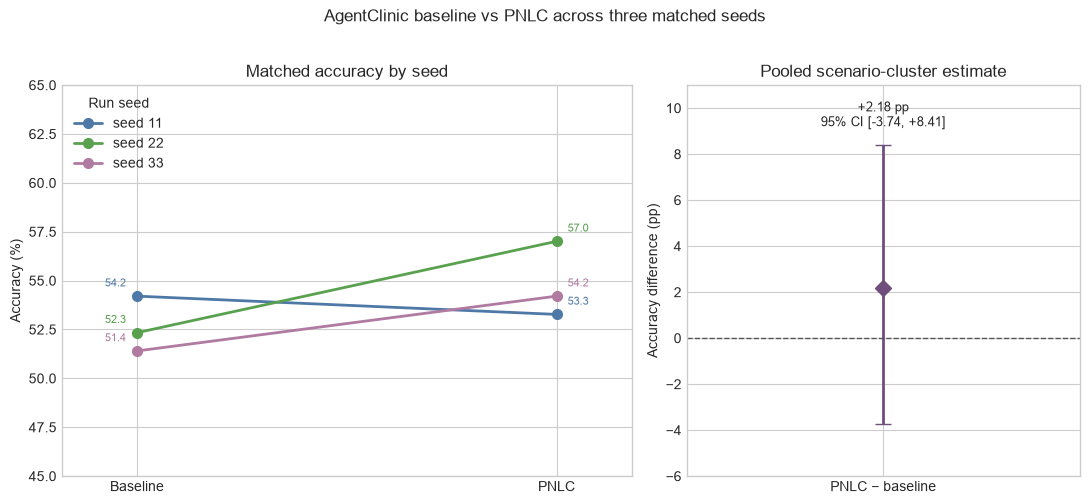

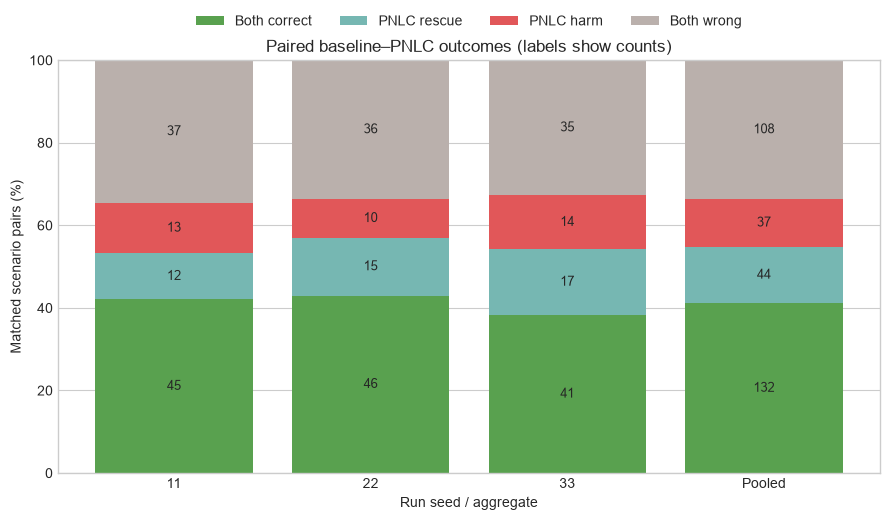

In [8]:
BASELINE_COLOR, PNLC_COLOR = '#4C78A8', '#F58518'
fig, (ax_accuracy, ax_effect) = plt.subplots(1, 2, figsize=(11, 4.9), gridspec_kw={'width_ratios': [1.45, 1]})
seed_colors = {11: '#4E79A7', 22: '#59A14F', 33: '#B07AA1'}
for row in seed_summary.itertuples():
    color = seed_colors[int(row.seed)]
    ax_accuracy.plot([0, 1], [100 * row.baseline_accuracy, 100 * row.pnlc_accuracy], color=color, marker='o', lw=2, ms=7, label=f'seed {row.seed}')
    ax_accuracy.annotate(f'{100 * row.baseline_accuracy:.1f}', (0, 100 * row.baseline_accuracy), xytext=(-8, 7), textcoords='offset points', ha='right', color=color, fontsize=8)
    ax_accuracy.annotate(f'{100 * row.pnlc_accuracy:.1f}', (1, 100 * row.pnlc_accuracy), xytext=(8, 7), textcoords='offset points', ha='left', color=color, fontsize=8)
ax_accuracy.set_xticks([0, 1], ['Baseline', 'PNLC'])
ax_accuracy.set_xlim(-0.18, 1.18); ax_accuracy.set_ylim(45, 65)
ax_accuracy.set_ylabel('Accuracy (%)'); ax_accuracy.set_title('Matched accuracy by seed')
ax_accuracy.legend(title='Run seed', frameon=False, loc='upper left')
pooled = pooled_summary.iloc[0]
lower_error = pooled.difference_pp - pooled.cluster_bootstrap_ci_low_pp
upper_error = pooled.cluster_bootstrap_ci_high_pp - pooled.difference_pp
ax_effect.errorbar([0], [pooled.difference_pp], yerr=[[lower_error], [upper_error]], fmt='D', ms=8, color='#6F4E7C', capsize=6, lw=2)
ax_effect.axhline(0, color='#555555', lw=1, ls='--')
ax_effect.set_xticks([0], ['PNLC − baseline']); ax_effect.set_xlim(-0.65, 0.65)
ax_effect.set_ylim(min(-6, pooled.cluster_bootstrap_ci_low_pp - 2), max(11, pooled.cluster_bootstrap_ci_high_pp + 2))
ax_effect.set_ylabel('Accuracy difference (pp)'); ax_effect.set_title('Pooled scenario-cluster estimate')
ax_effect.text(0, pooled.cluster_bootstrap_ci_high_pp + 0.8, f"{pooled.difference_pp:+.2f} pp\n95% CI [{pooled.cluster_bootstrap_ci_low_pp:+.2f}, {pooled.cluster_bootstrap_ci_high_pp:+.2f}]", ha='center', fontsize=9)
fig.suptitle('AgentClinic baseline vs PNLC across three matched seeds', y=1.02)
fig.tight_layout(); fig.savefig(FIGURE_DIR / 'agentclinic_multiseed_performance.png', dpi=180, bbox_inches='tight'); plt.show()

outcome_plot = seed_summary[['seed']].copy()
for outcome in OUTCOME_ORDER:
    outcome_plot[outcome] = seed_summary[outcome.lower().replace(' ', '_')]
pooled_plot = {'seed': 'Pooled', **{outcome: int(pooled_counts.get(outcome, 0)) for outcome in OUTCOME_ORDER}}
outcome_plot = pd.concat([outcome_plot, pd.DataFrame([pooled_plot])], ignore_index=True)
colors = ['#59A14F', '#76B7B2', '#E15759', '#BAB0AC']
fig, ax = plt.subplots(figsize=(9, 5.3))
denominators = np.array([107, 107, 107, 321], dtype=float)
bottom = np.zeros(len(outcome_plot))
for outcome, color in zip(OUTCOME_ORDER, colors):
    counts = outcome_plot[outcome].to_numpy(dtype=float)
    values = 100 * counts / denominators
    ax.bar(outcome_plot.seed.astype(str), values, bottom=bottom, label=outcome, color=color)
    for x, value, count, base in zip(range(len(values)), values, counts, bottom):
        if value >= 8: ax.text(x, base + value / 2, str(int(count)), ha='center', va='center', fontsize=9)
    bottom += values
ax.set_ylim(0, 100); ax.set_xlabel('Run seed / aggregate'); ax.set_ylabel('Matched scenario pairs (%)'); ax.set_title('Paired baseline–PNLC outcomes (labels show counts)')
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.14), frameon=False)
fig.tight_layout(); fig.savefig(FIGURE_DIR / 'agentclinic_multiseed_outcomes.png', dpi=180, bbox_inches='tight'); plt.show()


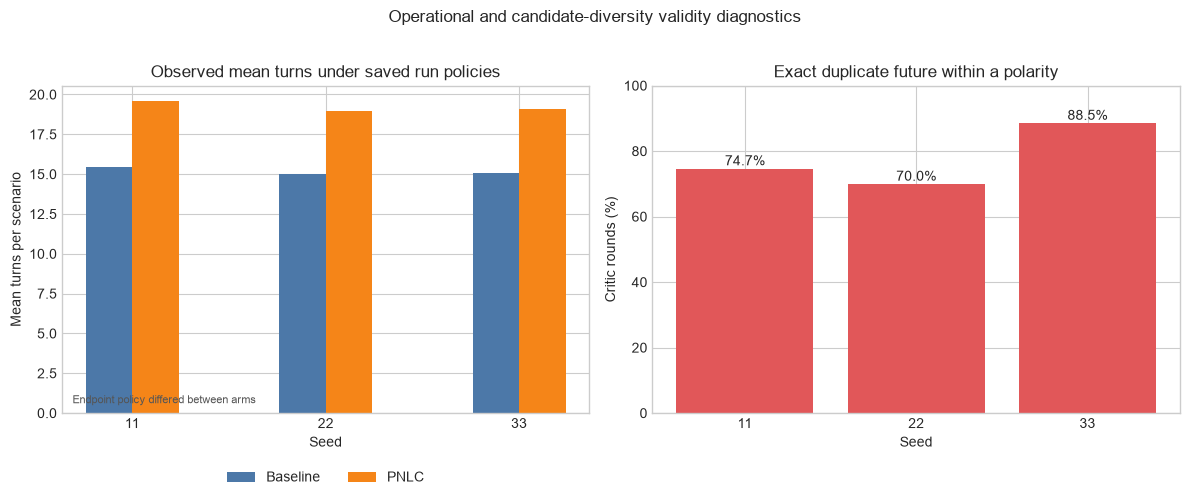

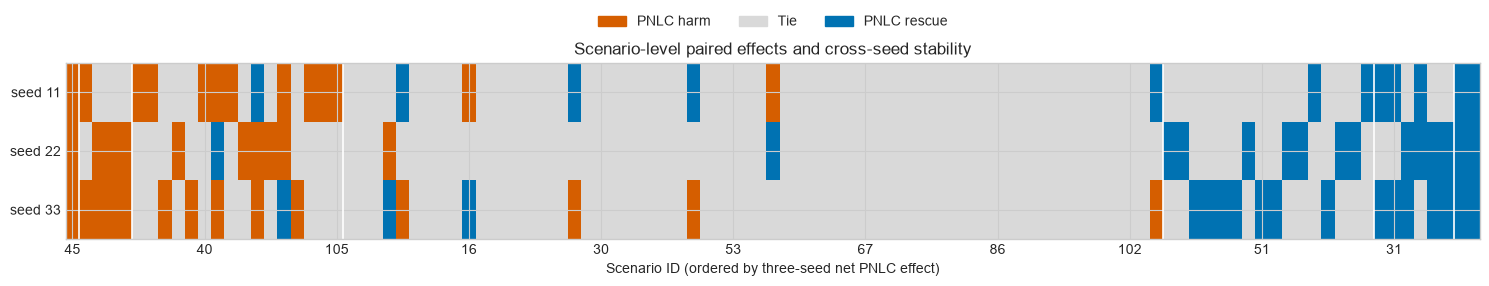

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for condition, color, offset in [('Baseline', BASELINE_COLOR, -0.12), ('PNLC', PNLC_COLOR, 0.12)]:
    subset = trajectory_summary[trajectory_summary.condition == condition].sort_values('seed')
    axes[0].bar(np.arange(len(subset)) + offset, subset.mean_turns, width=0.24, label=condition, color=color)
axes[0].set_xticks(range(3), seed_summary.seed.astype(str)); axes[0].set_xlabel('Seed'); axes[0].set_ylabel('Mean turns per scenario')
axes[0].set_title('Observed mean turns under saved run policies'); axes[0].legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2)
axes[0].text(0.02, 0.03, 'Endpoint policy differed between arms', transform=axes[0].transAxes, fontsize=8, color='#555555')
candidate_plot = candidate_summary.sort_values('seed')
axes[1].bar(candidate_plot.seed.astype(str), 100 * candidate_plot.any_duplicate_rate, color='#E15759')
for index, value in enumerate(candidate_plot.any_duplicate_rate): axes[1].text(index, 100 * value + 1, f'{value:.1%}', ha='center')
axes[1].set_ylim(0, 100); axes[1].set_xlabel('Seed'); axes[1].set_ylabel('Critic rounds (%)')
axes[1].set_title('Exact duplicate future within a polarity')
fig.suptitle('Operational and candidate-diversity validity diagnostics', y=1.02)
fig.tight_layout(); fig.subplots_adjust(bottom=0.18); fig.savefig(FIGURE_DIR / 'agentclinic_multiseed_validity_diagnostics.png', dpi=180, bbox_inches='tight'); plt.show()

stability_order = scenario_stability.sort_values(['net_delta', 'scenario_index']).scenario_index.tolist()
heat = pairs.pivot(index='seed', columns='scenario_index', values='delta').reindex(index=[11, 22, 33], columns=stability_order).to_numpy()
fig, ax = plt.subplots(figsize=(15, 3.2))
image = ax.imshow(heat, aspect='auto', cmap=ListedColormap(['#D55E00', '#D9D9D9', '#0072B2']), vmin=-1, vmax=1)
ax.set_yticks(range(3), ['seed 11', 'seed 22', 'seed 33'])
tick_positions = np.arange(0, len(stability_order), 10)
ax.set_xticks(tick_positions, [str(stability_order[position]) for position in tick_positions])
ax.set_xlabel('Scenario ID (ordered by three-seed net PNLC effect)')
ax.set_title('Scenario-level paired effects and cross-seed stability')
ordered_net = scenario_stability.set_index('scenario_index').loc[stability_order, 'net_delta'].to_numpy()
for boundary in np.flatnonzero(np.diff(ordered_net)) + 0.5:
    ax.axvline(boundary, color='white', lw=1.2)
ax.legend(handles=[Patch(color='#D55E00', label='PNLC harm'), Patch(color='#D9D9D9', label='Tie'), Patch(color='#0072B2', label='PNLC rescue')], ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.34), frameon=False)
fig.tight_layout(); fig.savefig(FIGURE_DIR / 'agentclinic_multiseed_scenario_stability.png', dpi=180, bbox_inches='tight'); plt.show()


## 6. Evidence-based assessment


In [10]:
baseline_turn_mean = turns_by_scenario[turns_by_scenario.condition == 'Baseline'].turns.mean()
pnlc_turn_mean = turns_by_scenario[turns_by_scenario.condition == 'PNLC'].turns.mean()
display(Markdown(f"""
### What these six runs currently say

- Baseline is **{int(pooled.baseline_correct)}/321 = {pooled.baseline_accuracy:.2%}** and PNLC is **{int(pooled.pnlc_correct)}/321 = {pooled.pnlc_accuracy:.2%}**. The paired difference is **{pooled.difference_pp:+.2f} percentage points**, with a scenario-cluster bootstrap 95% CI of **[{pooled.cluster_bootstrap_ci_low_pp:+.2f}, {pooled.cluster_bootstrap_ci_high_pp:+.2f}] pp** and sign-flip p = **{pooled.cluster_signflip_p:.3f}**. This is compatible with modest harm, no effect, or modest benefit; it is not evidence of a reliable improvement. The interval is conditional on seeds 11, 22, and 33 and does not estimate variation over all possible seeds.
- PNLC rescues **{int(pooled.pnlc_rescue)}** scenario-seed pairs but harms **{int(pooled.pnlc_harm)}**. Those transitions are the useful mechanism cases; aggregate accuracy alone cannot tell whether a correction was absent from the candidate pool, misranked by the critic, or ignored by the doctor.
- PNLC averages **{pnlc_turn_mean:.2f}** turns versus **{baseline_turn_mean:.2f}** for baseline, an increase of **{(pnlc_turn_mean / baseline_turn_mean - 1):.1%}**.
- The largest validity failure is candidate collapse: **{pooled_duplicate_rate:.1%}** of scored critic rounds contain an exact duplicate within the positive or negative pair. These runs were generated before the diversity/resampling fix and must be rerun.
- The saved generation policy also enforced the last-turn diagnosis instruction asymmetrically, and the run files lack model/checkpoint/config/code hashes. The seed-22 duplicate run changes correctness on **{int((~repeat_pair.same_correctness).sum())}/107** scenarios, underscoring the need for complete provenance and matched reruns.
- Accuracy labels are still evaluator-conditional: the repository's independent adjudication covers older runs, not these six seeded artifacts.

**Conclusion:** these runs are useful pilot evidence and produce a concrete mechanism-review set, but they neither confirm nor refute the critic-inheritance hypothesis. The next defensible experiment is the same three-seed comparison rerun with distinct candidates, symmetric endpoint handling, complete provenance, and blinded adjudication of rescues/harms.
"""))



### What these six runs currently say

- Baseline is **169/321 = 52.65%** and PNLC is **176/321 = 54.83%**. The paired difference is **+2.18 percentage points**, with a scenario-cluster bootstrap 95% CI of **[-3.74, +8.41] pp** and sign-flip p = **0.550**. This is compatible with modest harm, no effect, or modest benefit; it is not evidence of a reliable improvement. The interval is conditional on seeds 11, 22, and 33 and does not estimate variation over all possible seeds.
- PNLC rescues **44** scenario-seed pairs but harms **37**. Those transitions are the useful mechanism cases; aggregate accuracy alone cannot tell whether a correction was absent from the candidate pool, misranked by the critic, or ignored by the doctor.
- PNLC averages **19.21** turns versus **15.19** for baseline, an increase of **26.5%**.
- The largest validity failure is candidate collapse: **77.7%** of scored critic rounds contain an exact duplicate within the positive or negative pair. These runs were generated before the diversity/resampling fix and must be rerun.
- The saved generation policy also enforced the last-turn diagnosis instruction asymmetrically, and the run files lack model/checkpoint/config/code hashes. The seed-22 duplicate run changes correctness on **19/107** scenarios, underscoring the need for complete provenance and matched reruns.
- Accuracy labels are still evaluator-conditional: the repository's independent adjudication covers older runs, not these six seeded artifacts.

**Conclusion:** these runs are useful pilot evidence and produce a concrete mechanism-review set, but they neither confirm nor refute the critic-inheritance hypothesis. The next defensible experiment is the same three-seed comparison rerun with distinct candidates, symmetric endpoint handling, complete provenance, and blinded adjudication of rescues/harms.


## 7. Inspect an individual matched trajectory

Call `show_scenario(scenario_index, seed)` to inspect the matched dialogue. It exposes the critic's goals and scores without pretending that exact text differences are semantic causal evidence.


In [11]:
def show_scenario(scenario_index, seed):
    scenario_index, seed = int(scenario_index), int(seed)
    if scenario_index not in range(107) or seed not in {11, 22, 33}:
        raise ValueError('scenario_index must be 0–106 and seed must be 11, 22, or 33')
    pair = pairs[(pairs.scenario_index == scenario_index) & (pairs.seed == seed)].iloc[0]
    display(Markdown(f"""### Scenario {scenario_index}, seed {seed}
**Reference:** {references[scenario_index]}  
**Outcome:** {pair.outcome}  
**Baseline:** {pair.doctor_diagnosis_text_baseline or '[no diagnosis]'}  
**PNLC:** {pair.doctor_diagnosis_text_pnlc or '[no diagnosis]'}  
**Question:** {questions[scenario_index]}"""))
    baseline = trajectories[(trajectories.condition == 'Baseline') & (trajectories.seed == seed) & (trajectories.scenario_index == scenario_index)]
    pnlc = trajectories[(trajectories.condition == 'PNLC') & (trajectories.seed == seed) & (trajectories.scenario_index == scenario_index)]
    baseline_by_turn = {int(item.turn_index): item for item in baseline.itertuples()}
    pnlc_by_turn = {int(item.turn_index): item for item in pnlc.itertuples()}
    rows = []
    for turn in sorted(set(baseline_by_turn) | set(pnlc_by_turn)):
        baseline_item = baseline_by_turn.get(turn)
        pnlc_item = pnlc_by_turn.get(turn)
        critic = pnlc_item.critic if pnlc_item is not None and isinstance(pnlc_item.critic, dict) else {}
        assessments = []
        for round_index, critic_round in enumerate(critic.get('rounds', []), start=1):
            for assessment in critic_round.get('assessments', []):
                assessments.append(f"r{round_index} {assessment.get('polarity')}: {assessment.get('raw_score', float('nan')):.3f} | {assessment.get('goal', '')}")
        rows.append({
            'turn': turn, 'baseline_incoming_message': baseline_item.incoming_message if baseline_item is not None else '[trajectory ended]',
            'pnlc_incoming_message': pnlc_item.incoming_message if pnlc_item is not None else '[trajectory ended]',
            'baseline_action': baseline_item.doctor_action if baseline_item is not None else '[trajectory ended]',
            'pnlc_initial_action': critic.get('initial_action', '[critic fallback]' if pnlc_item is not None else '[trajectory ended]'),
            'pnlc_final_action': pnlc_item.doctor_action if pnlc_item is not None else '[trajectory ended]',
            'critic_assessments': '\n'.join(assessments),
        })
    table = pd.DataFrame(rows)
    display(table)
    return table

# Examples worth adjudicating first: scenario 45 is harmed in all three seeds;
# scenarios 81 and 84 are rescued in all three seeds.
# show_scenario(45, 11)
